<a href="https://colab.research.google.com/github/Tenzin-Phende/sarcasm-embedding-analysis/blob/main/Word2Vec_%26_BERT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas numpy scikit-learn gensim torch torchvision torchaudio transformers matplotlib seaborn tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 85.1 MB/s eta 0:00:00


In [ ]:
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_fscore_support, silhouette_score
from sklearn.metrics.pairwise import cosine_distances
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from gensim.models import Word2Vec

import torch
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertModel

from tqdm.auto import tqdm

sns.set(style="whitegrid", context="talk")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cpu


In [ ]:
DATA_PATH = "Sarcasm_Headlines_Dataset_v2.json"  # Change path if needed

# Load JSON lines
records = []
with open(DATA_PATH, "r", encoding="utf-8") as f:
    for line in f:
        records.append(json.loads(line))

df = pd.DataFrame(records)
df = df.rename(columns={"headline": "text", "is_sarcastic": "label"})
df = df[["text", "label"]]

print("Dataset stats (for Section 3.1):")
print(df["label"].value_counts())
print(f"Total samples: {len(df)}")
df.head()


Dataset stats (for Section 3.1):
label
0    14985
1    13634
Name: count, dtype: int64
Total samples: 28619


,text,label
0,thirtysomething scientists unveil doomsday clo...,1
1,dem rep. totally nails why congress is falling...,0
2,eat your veggies: 9 deliciously different recipes,0
3,inclement weather prevents liar from getting t...,1
4,mother comes pretty close to using word 'strea...,1


In [ ]:
def clean_text(s):
    s = s.lower()
    s = re.sub(r"http\S+|www\.\S+", " ", s)  # remove URLs
    s = re.sub(r"\s+", " ", s).strip()       # normalize spaces
    return s

df["text_clean"] = df["text"].astype(str).apply(clean_text)

# 70/15/15 split with seed 42
train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df["label"], random_state=42
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df["label"], random_state=42
)

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

# Tokenize for Word2Vec
def simple_tokenize(s):
    return s.split()

train_df["tokens"] = train_df["text_clean"].apply(simple_tokenize)
val_df["tokens"] = val_df["text_clean"].apply(simple_tokenize)
test_df["tokens"] = test_df["text_clean"].apply(simple_tokenize)

train_df[["text_clean", "tokens"]].head()


Train: 20033, Val: 4293, Test: 4293


,text_clean,tokens
24819,the most dangerous beaches for shark attacks i...,"[the, most, dangerous, beaches, for, shark, at..."
11682,frustrated man doesn't know what else he can d...,"[frustrated, man, doesn't, know, what, else, h..."
2096,americans more polarized than at any time in l...,"[americans, more, polarized, than, at, any, ti..."
5230,megachurch threatened by new ultrachurch,"[megachurch, threatened, by, new, ultrachurch]"
7238,dog waited in this spot for a month for her fa...,"[dog, waited, in, this, spot, for, a, month, f..."


In [ ]:
# Train Word2Vec on training tokens only
w2v_sentences = train_df["tokens"].tolist()

w2v_model = Word2Vec(
    sentences=w2v_sentences,
    vector_size=300,
    window=5,
    min_count=2,
    workers=4,
    sg=1,       # Skip-gram
    epochs=10,
    seed=42
)

print(w2v_model)


Word2Vec<vocab=13509, vector_size=300, alpha=0.025>


In [ ]:
def sentence_embedding_w2v(tokens, model, dim=300):
    vecs = [model.wv[tok] for tok in tokens if tok in model.wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(dim, dtype=np.float32)

def embed_split_w2v(df_split, model):
    X = np.array([sentence_embedding_w2v(tokens, model) for tokens in df_split["tokens"]])
    y = df_split["label"].values.astype(int)
    return X, y

X_train_w2v, y_train_w2v = embed_split_w2v(train_df, w2v_model)
X_val_w2v, y_val_w2v = embed_split_w2v(val_df, w2v_model)
X_test_w2v, y_test_w2v = embed_split_w2v(test_df, w2v_model)

print("Word2Vec shapes:", X_train_w2v.shape, X_val_w2v.shape, X_test_w2v.shape)


Word2Vec shapes: (20033, 300) (4293, 300) (4293, 300)


In [ ]:
bert_model_name = "bert-base-uncased"
tokenizer = BertTokenizer.from_pretrained(bert_model_name)
bert_model = BertModel.from_pretrained(bert_model_name)
bert_model.to(device)
bert_model.eval()
print("BERT loaded!")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERT loaded!


In [ ]:
MAX_LEN = 32
BATCH_SIZE = 32

class HeadlineDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = list(texts)
        self.labels = list(labels)

    def __len__(self): return len(self.texts)
    def __getitem__(self, idx): return self.texts[idx], self.labels[idx]

def collate_batch(batch):
    texts, labels = zip(*batch)
    enc = tokenizer(list(texts), padding=True, truncation=True,
                    max_length=MAX_LEN, return_tensors="pt")
    return enc, torch.tensor(labels, dtype=torch.long)

train_ds = HeadlineDataset(train_df["text_clean"], train_df["label"])
val_ds = HeadlineDataset(val_df["text_clean"], val_df["label"])
test_ds = HeadlineDataset(test_df["text_clean"], test_df["label"])

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_batch)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_batch)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_batch)


In [ ]:
def extract_bert_embeddings(dataloader, model, device):
    all_cls, all_mean, all_labels = [], [], []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Extracting"):
            enc, labels = batch
            input_ids = enc["input_ids"].to(device)
            attention_mask = enc["attention_mask"].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            last_hidden_state = outputs.last_hidden_state  # FIXED: was missing this line

            # CLS embedding (first token)
            cls_emb = last_hidden_state[:, 0, :]

            # Mean pool (only non-padding tokens)
            mask = attention_mask.unsqueeze(-1).float()
            sum_emb = (last_hidden_state * mask).sum(dim=1)
            lengths = mask.sum(dim=1)
            mean_emb = sum_emb / lengths

            all_cls.append(cls_emb.cpu().numpy())
            all_mean.append(mean_emb.cpu().numpy())
            all_labels.append(labels.numpy())

    return (np.vstack(all_cls), np.vstack(all_mean), np.concatenate(all_labels))

print("Extracting BERT embeddings...")
X_train_bert_cls, X_train_bert_mean, y_train_bert = extract_bert_embeddings(train_loader, bert_model, device)
X_val_bert_cls, X_val_bert_mean, y_val_bert = extract_bert_embeddings(val_loader, bert_model, device)
X_test_bert_cls, X_test_bert_mean, y_test_bert = extract_bert_embeddings(test_loader, bert_model, device)

print("BERT shapes:", X_test_bert_cls.shape)
print("Labels match:", np.all(y_test_w2v == y_test_bert))


Extracting BERT embeddings...


Extracting:   0%|          | 0/627 [00:00<?, ?it/s]

Extracting:   0%|          | 0/135 [00:00<?, ?it/s]

Extracting:   0%|          | 0/135 [00:00<?, ?it/s]

BERT shapes: (4293, 768)
Labels match: True


In [ ]:
# Intra/inter-class distances + silhouette
def intra_inter_cosine(X, y, max_samples=1000, seed=42):
    np.random.seed(seed)
    classes = np.unique(y)
    results = {}

    # Intra-class (per class)
    for c in classes:
        idx_c = np.where(y == c)[0]
        if len(idx_c) > max_samples:
            idx_c = np.random.choice(idx_c, max_samples, replace=False)
        X_c = X[idx_c]
        D_c = cosine_distances(X_c)
        triu = np.triu_indices_from(D_c, k=1)
        intra = D_c[triu].mean() if len(triu[0]) > 0 else np.nan
        results[int(c)] = {"intra": intra}

    # Inter-class (0 vs 1)
    idx0, idx1 = np.where(y == 0)[0], np.where(y == 1)[0]
    if len(idx0) > max_samples: idx0 = np.random.choice(idx0, max_samples, replace=False)
    if len(idx1) > max_samples: idx1 = np.random.choice(idx1, max_samples, replace=False)
    D_inter = cosine_distances(X[idx0], X[idx1])
    inter = D_inter.mean()

    return results, inter

def compute_metrics(X, y, name):
    print(f"\n=== {name} ===")

    # Silhouette (subsample for speed)
    if len(y) > 2000:
        idx = np.random.choice(len(y), 2000, replace=False)
        sil = silhouette_score(X[idx], y[idx], metric="cosine")
    else:
        sil = silhouette_score(X, y, metric="cosine")

    intra, inter = intra_inter_cosine(X, y)

    print(f"Silhouette: {sil:.4f}")
    print(f"Inter-class distance: {inter:.4f}")
    print(f"Class 0 intra: {intra[0]['intra']:.4f}")
    print(f"Class 1 intra: {intra[1]['intra']:.4f}")

    return {"silhouette": sil, "inter": inter, **intra[0], **intra[1]}

# Run for all embeddings (TEST set only)
metrics = {}
metrics["w2v"] = compute_metrics(X_test_w2v, y_test_w2v, "Word2Vec")
metrics["bert_cls"] = compute_metrics(X_test_bert_cls, y_test_bert, "BERT-CLS")
metrics["bert_mean"] = compute_metrics(X_test_bert_mean, y_test_bert, "BERT-mean")



=== Word2Vec ===
Silhouette: 0.0686
Inter-class distance: 0.1813
Class 0 intra: 0.1740
Class 1 intra: 0.1628

=== BERT-CLS ===
Silhouette: 0.0409
Inter-class distance: 0.2629
Class 0 intra: 0.2483
Class 1 intra: 0.2539

=== BERT-mean ===
Silhouette: 0.0376
Inter-class distance: 0.4293
Class 0 intra: 0.4191
Class 1 intra: 0.4074


In [ ]:
def run_logreg(X_train, y_train, X_test, y_test, name, R=5):
    f1_scores = []
    for r in range(R):
        clf = LogisticRegression(max_iter=1000, C=1.0, random_state=42+r, n_jobs=-1)
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        _, _, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="binary")
        f1_scores.append(f1)

    mean_f1 = np.mean(f1_scores)
    std_f1 = np.std(f1_scores, ddof=1)
    print(f"{name} F1: {mean_f1:.4f} ± {std_f1:.4f}")
    return mean_f1, std_f1

print("\n=== Logistic Regression F1 Scores ===")
f1_w2v = run_logreg(X_train_w2v, y_train_w2v, X_test_w2v, y_test_w2v, "Word2Vec")
f1_bert_cls = run_logreg(X_train_bert_cls, y_train_bert, X_test_bert_cls, y_test_bert, "BERT-CLS")
f1_bert_mean = run_logreg(X_train_bert_mean, y_train_bert, X_test_bert_mean, y_test_bert, "BERT-mean")



=== Logistic Regression F1 Scores ===
Word2Vec F1: 0.7941 ± 0.0000
BERT-CLS F1: 0.8562 ± 0.0000
BERT-mean F1: 0.8574 ± 0.0000


In [ ]:
table_data = {
    "Model": ["Word2Vec", "BERT-CLS", "BERT-mean"],
    "Silhouette": [metrics["w2v"]["silhouette"],
                   metrics["bert_cls"]["silhouette"],
                   metrics["bert_mean"]["silhouette"]],
    "Intra-0": [metrics["w2v"]["intra"],
                metrics["bert_cls"]["intra"],
                metrics["bert_mean"]["intra"]],
    "Intra-1": [metrics["w2v"]["intra"],
                metrics["bert_cls"]["intra"],
                metrics["bert_mean"]["intra"]],
    "Inter": [metrics["w2v"]["inter"],
              metrics["bert_cls"]["inter"],
              metrics["bert_mean"]["inter"]],
    "F1": [f1_w2v[0], f1_bert_cls[0], f1_bert_mean[0]],
    "±std": [f"±{f1_w2v[1]:.4f}", f"±{f1_bert_cls[1]:.4f}", f"±{f1_bert_mean[1]:.4f}"]
}

table_df = pd.DataFrame(table_data)
table_df = table_df.round(4)
print("\n=== TABLE 1 FOR YOUR REPORT ===")
print(table_df.to_string(index=False))
print("\nLaTeX version:")
print(table_df.to_latex(index=False, float_format="%.4f", escape=False))



=== TABLE 1 FOR YOUR REPORT ===
    Model  Silhouette  Intra-0  Intra-1  Inter     F1    ±std
 Word2Vec      0.0686   0.1628   0.1628 0.1813 0.7941 ±0.0000
 BERT-CLS      0.0409   0.2539   0.2539 0.2629 0.8562 ±0.0000
BERT-mean      0.0376   0.4074   0.4074 0.4293 0.8574 ±0.0000

LaTeX version:
\begin{tabular}{lrrrrrl}
\toprule
Model & Silhouette & Intra-0 & Intra-1 & Inter & F1 & ±std \\
\midrule
Word2Vec & 0.0686 & 0.1628 & 0.1628 & 0.1813 & 0.7941 & ±0.0000 \\
BERT-CLS & 0.0409 & 0.2539 & 0.2539 & 0.2629 & 0.8562 & ±0.0000 \\
BERT-mean & 0.0376 & 0.4074 & 0.4074 & 0.4293 & 0.8574 & ±0.0000 \\
\bottomrule
\end{tabular}



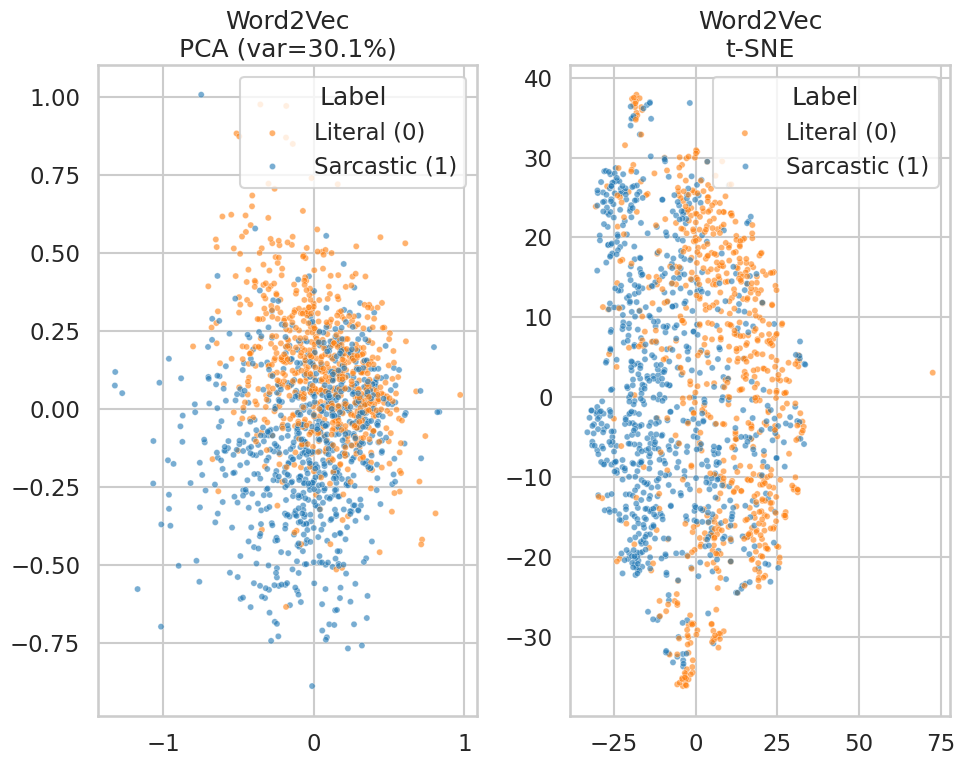

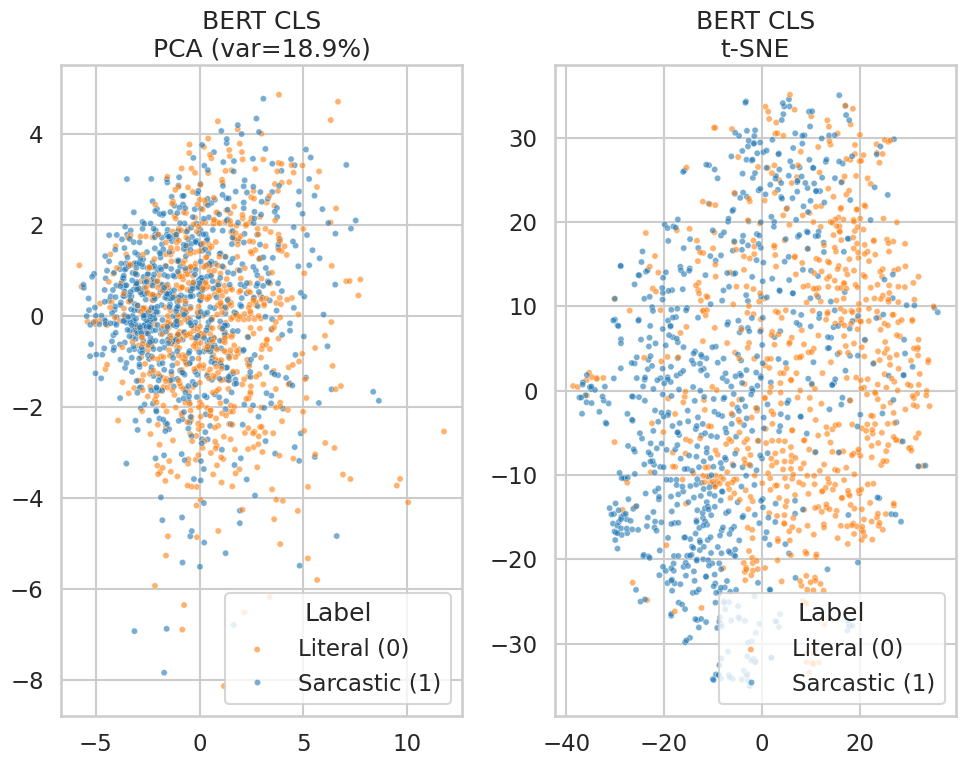

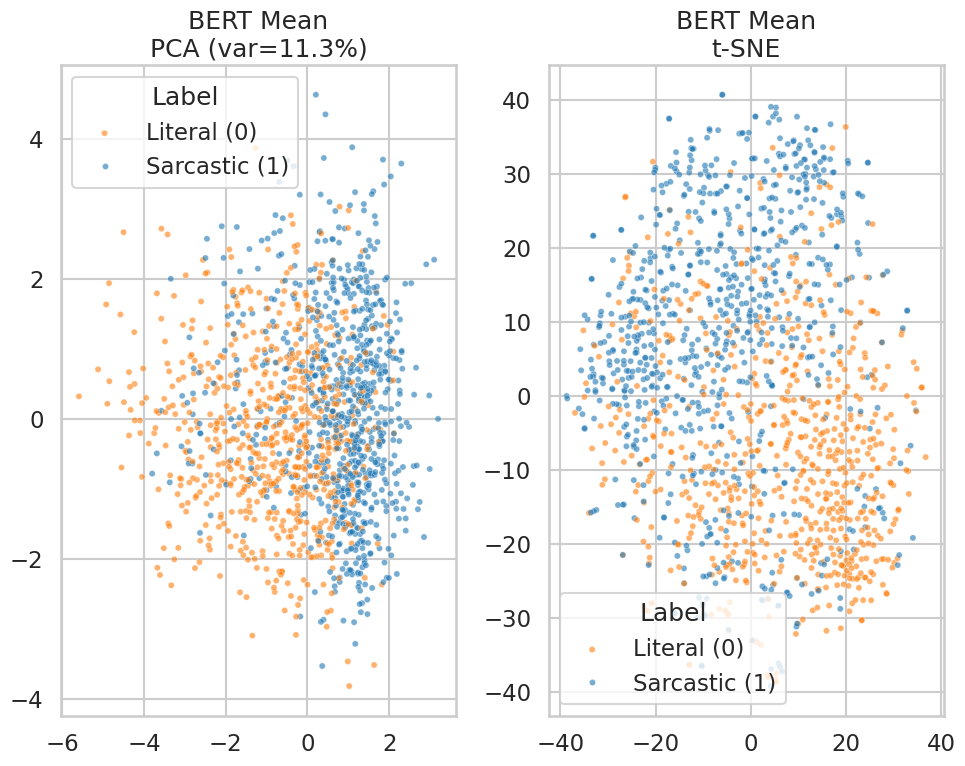

In [ ]:
def plot_embeddings(X, y, title, sample_size=1500, figsize=(10, 8)):
    np.random.seed(42)
    idx = np.arange(len(y))
    if len(y) > sample_size:
        idx = np.random.choice(idx, sample_size, replace=False)
    X_sub, y_sub = X[idx], y[idx]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)

    # PCA
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_sub)
    var_exp = pca.explained_variance_ratio_.sum()
    sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=y_sub,
                    palette=['#1f77b4', '#ff7f0e'], alpha=0.6, s=20, ax=ax1)
    ax1.set_title(f'{title}\nPCA (var={var_exp:.1%})')
    ax1.legend(title='Label', labels=['Literal (0)', 'Sarcastic (1)'])

    # t-SNE
    tsne = TSNE(n_components=2, perplexity=30, random_state=42,
                init='pca', metric='cosine')
    X_tsne = tsne.fit_transform(X_sub)
    sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], hue=y_sub,
                    palette=['#1f77b4', '#ff7f0e'], alpha=0.6, s=20, ax=ax2)
    ax2.set_title(f'{title}\nt-SNE')
    ax2.legend(title='Label', labels=['Literal (0)', 'Sarcastic (1)'])

    plt.tight_layout()
    plt.savefig(f'{title.replace(" ", "_")}.png', dpi=300, bbox_inches='tight')
    plt.show()

# Generate your 3 figures!
plot_embeddings(X_test_w2v, y_test_w2v, "Word2Vec")
plot_embeddings(X_test_bert_cls, y_test_bert, "BERT CLS")
plot_embeddings(X_test_bert_mean, y_test_bert, "BERT Mean")


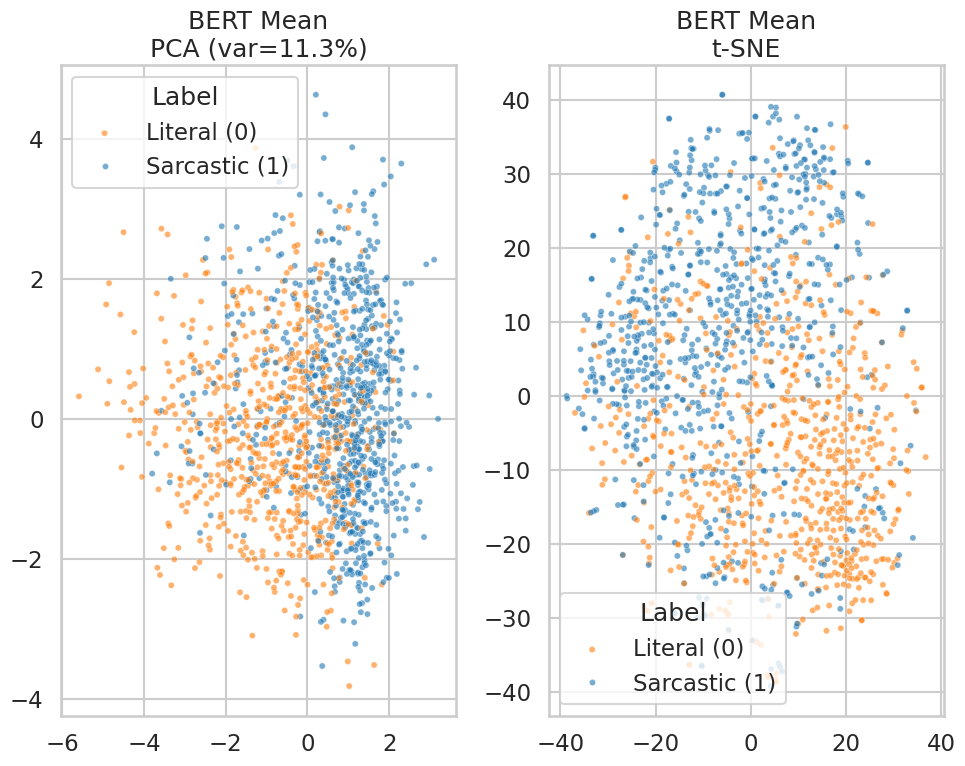

In [ ]:
plot_embeddings(X_test_bert_mean, y_test_bert, "BERT Mean")